# Attention Core: From Dot Products To SDPA

We start with one attention head. Multi-head attention is this same logic run in
parallel across heads.

We are going to build attention from the bottom up:

1. Write dot product, matrix multiplication, max, exp, sum, and softmax with plain Python loops.
2. Rebuild the same attention operation with NumPy vector operations.
3. Move the same logic to Torch eager tensors.
4. Add Q/K/V projection, causal prefill, and decode with a KV cache.
5. Compare our implementation with Torch native SDPA.
6. Try `torch.compile` and benchmark after warmup.
7. Use the profiler to see which Torch operators actually run.

The goal is to understand the operation deeply enough that later notebooks on
FlashAttention, FlexAttention, and kernel notebooks have a clear base
to build on.


## Setup


In [63]:
import math
import platform

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from torch.profiler import ProfilerActivity, profile
from torch.utils.benchmark import Timer

torch.manual_seed(0)
np.random.seed(0)
torch.set_printoptions(precision=4, sci_mode=False)
np.set_printoptions(precision=4, suppress=True)

def print_table(headers, rows):
    widths = [len(str(header)) for header in headers]
    for row in rows:
        for idx, value in enumerate(row):
            widths[idx] = max(widths[idx], len(str(value)))
    template = "  ".join(f"{{:<{width}}}" for width in widths)
    print(template.format(*headers))
    print(template.format(*["-" * width for width in widths]))
    for row in rows:
        print(template.format(*[str(value) for value in row]))

## Runtime And Device

We record the runtime before benchmarking. When this notebook is run on a GPU
runtime, the table below shows the CUDA device used for Torch GPU measurements.


In [64]:
def runtime_rows():
    cuda_available = torch.cuda.is_available()
    mps_available = hasattr(torch.backends, "mps") and torch.backends.mps.is_available()
    if cuda_available:
        accelerator = torch.cuda.get_device_name(0)
    elif mps_available:
        accelerator = "Apple MPS"
    else:
        accelerator = "CPU"

    return [
        ["python", platform.python_version()],
        ["torch", torch.__version__],
        ["cuda_available", cuda_available],
        ["cuda_device_count", torch.cuda.device_count() if cuda_available else 0],
        ["accelerator", accelerator],
    ]


print_table(["runtime", "value"], runtime_rows())


runtime            value       
-----------------  ------------
python             3.12.13     
torch              2.11.0+cu128
cuda_available     True        
cuda_device_count  1           
accelerator        Tesla T4    


In [65]:
!nvidia-smi

Thu Jun  4 10:50:54 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   43C    P0             25W /   70W |     263MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Shape Notation

We use one attention head in this notebook:

- `B`: batch size
- `T`: number of token positions
- `C`: model hidden size before attention projection
- `D`: attention width after projection

```text
x:       [B, T, C]
q, k, v: [B, T, D]
scores:  [B, T_query, T_key]
weights: [B, T_query, T_key]
out:     [B, T_query, D]
```

There is no head axis yet. Notebook 02 adds it:

```text
single-head: [B, T, D]
multi-head:  [B, H, T, D]
```

In [66]:
B = 2
T = 8
C = 12
D = 6

print_table(
    ["tensor", "shape", "meaning"],
    [
        ["x", [B, T, C], "input hidden states"],
        ["q", [B, T, D], "what each token asks for"],
        ["k", [B, T, D], "what each token offers for matching"],
        ["v", [B, T, D], "information mixed into the output"],
        ["scores", [B, T, T], "query-key similarities"],
        ["weights", [B, T, T], "softmax probabilities"],
        ["out", [B, T, D], "weighted value mixture"],
    ],
)

tensor   shape       meaning                            
-------  ----------  -----------------------------------
x        [2, 8, 12]  input hidden states                
q        [2, 8, 6]   what each token asks for           
k        [2, 8, 6]   what each token offers for matching
v        [2, 8, 6]   information mixed into the output  
scores   [2, 8, 8]   query-key similarities             
weights  [2, 8, 8]   softmax probabilities              
out      [2, 8, 6]   weighted value mixture             


## Plain Python: Attention Without Array Libraries

Before NumPy or Torch, we write the pieces directly.

This version is deliberately slow and small. It exposes the operations:

- dot product
- matrix multiplication
- square-root scaling
- max subtraction for stable softmax
- exponential
- sum
- weighted value mixing

In [67]:
def manual_sqrt(x, iterations=20):
    if x < 0:
        raise ValueError("sqrt is undefined for negative numbers.")
    if x == 0:
        return 0.0
    guess = x if x >= 1 else 1.0
    for _ in range(iterations):
        guess = 0.5 * (guess + x / guess)
    return guess


def manual_exp(x, terms=40):
    # Taylor series. Stable enough here because softmax subtracts the max first.
    if x < 0:
        return 1.0 / manual_exp(-x, terms=terms)
    result = 1.0
    term = 1.0
    for n in range(1, terms):
        term = term * x / n
        result = result + term
    return result


def manual_sum(values):
    total = 0.0
    for value in values:
        total += value
    return total


def manual_max(values):
    if not values:
        raise ValueError("manual_max needs at least one value.")
    max_value = values[0]
    for value in values[1:]:
        if value > max_value:
            max_value = value
    return max_value


def manual_dot(left, right):
    if len(left) != len(right):
        raise ValueError("dot product inputs must have the same length.")
    total = 0.0
    for idx in range(len(left)):
        total += left[idx] * right[idx]
    return total


def manual_transpose(matrix):
    rows = len(matrix)
    cols = len(matrix[0])
    return [[matrix[row][col] for row in range(rows)] for col in range(cols)]


def manual_matmul(left, right):
    # left: [M, N], right: [N, P], output: [M, P]
    right_t = manual_transpose(right)
    output = []
    for left_row in left:
        output_row = []
        for right_col in right_t:
            output_row.append(manual_dot(left_row, right_col))
        output.append(output_row)
    return output

## Plain Python Softmax And Attention

Softmax is not just `exp(x) / sum(exp(x))` in code. We subtract the row max first
so large scores do not overflow:

```text
softmax(x_i) = exp(x_i - max(x)) / sum_j exp(x_j - max(x))
```

The causal mask is also explicit: future scores become `-inf`, and their softmax
probability becomes zero.

In [68]:
def manual_softmax(values):
    row_max = manual_max(values)
    exp_values = []
    for value in values:
        if value == float("-inf"):
            exp_values.append(0.0)
        else:
            exp_values.append(manual_exp(value - row_max))
    denominator = manual_sum(exp_values)
    return [value / denominator for value in exp_values]


def attention_plain_python(q, k, v, *, causal=False):
    # q: [T_query, D]
    # k: [T_key, D]
    # v: [T_key, D]
    scores = manual_matmul(q, manual_transpose(k))
    scale = manual_sqrt(len(q[0]))

    for query_idx in range(len(scores)):
        for key_idx in range(len(scores[query_idx])):
            scores[query_idx][key_idx] = scores[query_idx][key_idx] / scale
            if causal and key_idx > query_idx:
                scores[query_idx][key_idx] = float("-inf")

    weights = [manual_softmax(row) for row in scores]
    output = manual_matmul(weights, v)
    return output, weights, scores


q_plain = [
    [1.0, 0.0],
    [0.0, 1.0],
    [0.7, 0.7],
]
k_plain = [
    [1.0, 0.0],
    [0.0, 1.0],
    [0.7, 0.7],
]
v_plain = [
    [10.0, 0.0],
    [0.0, 10.0],
    [5.0, 5.0],
]

plain_out, plain_weights, plain_scores = attention_plain_python(
    q_plain,
    k_plain,
    v_plain,
    causal=True,
)

def rounded_matrix(matrix):
    return [
        [round(value, 4) if value != float("-inf") else "-inf" for value in row]
        for row in matrix
    ]


print_table(
    ["check", "value"],
    [
        ["sqrt(2)", round(manual_sqrt(2.0), 6)],
        ["exp(1)", round(manual_exp(1.0), 6)],
    ],
)

print("scores:")
for row in rounded_matrix(plain_scores):
    print(row)

print("\nweights:")
for row in rounded_matrix(plain_weights):
    print(row)

print("\noutput:")
for row in rounded_matrix(plain_out):
    print(row)


check    value   
-------  --------
sqrt(2)  1.414214
exp(1)   2.718282
scores:
[0.7071, '-inf', '-inf']
[0.0, 0.7071, '-inf']
[0.495, 0.495, 0.693]

weights:
[1.0, 0.0, 0.0]
[0.3302, 0.6698, 0.0]
[0.3107, 0.3107, 0.3787]

output:
[10.0, 0.0]
[3.3024, 6.6976]
[5.0, 5.0]


## NumPy: The Same Toy With Vector Operations

Now compress the one-query example into NumPy operations. The result should feel
less mysterious because we already wrote the dot product, max, exp, sum, and
weighted value mixing by hand.


In [69]:
query_np = np.array([1.0, 0.0])
keys_np = np.array(
    [
        [1.0, 0.0],
        [0.0, 1.0],
        [0.7, 0.7],
    ]
)
values_np = np.array(
    [
        [10.0, 0.0],
        [0.0, 10.0],
        [5.0, 5.0],
    ]
)

scores_np = query_np @ keys_np.T / math.sqrt(query_np.shape[-1])
weights_np = np.exp(scores_np - scores_np.max())
weights_np = weights_np / weights_np.sum()
output_np = weights_np @ values_np

print_table(
    ["item", "value"],
    [
        ["scores", np.round(scores_np, 4).tolist()],
        ["weights", np.round(weights_np, 4).tolist()],
        ["output", np.round(output_np, 4).tolist()],
    ],
)

item     value                   
-------  ------------------------
scores   [0.7071, 0.0, 0.495]    
weights  [0.4344, 0.2142, 0.3514]
output   [6.1011, 3.8989]        


## Causal Mask

Decoder attention must not read future tokens.

In prefill, all prompt positions are present together, so future keys exist in
the same score matrix. The causal mask blocks them before softmax.

In [70]:
def causal_mask_np(query_len, key_len):
    q_pos = np.arange(query_len)[:, None]
    k_pos = np.arange(key_len)[None, :]
    offset = key_len - query_len
    return k_pos <= q_pos + offset


def causal_mask_torch(query_len, key_len, device=None):
    q_pos = torch.arange(query_len, device=device)[:, None]
    k_pos = torch.arange(key_len, device=device)[None, :]
    offset = key_len - query_len
    return k_pos <= q_pos + offset


print(causal_mask_np(6, 6).astype(int))

[[1 0 0 0 0 0]
 [1 1 0 0 0 0]
 [1 1 1 0 0 0]
 [1 1 1 1 0 0]
 [1 1 1 1 1 0]
 [1 1 1 1 1 1]]


## NumPy: Batched Causal Attention

This is the full attention primitive in NumPy. It still materializes the full
score matrix, but now the loops are inside NumPy instead of our Python code.


In [71]:
def softmax_np(x, axis=-1):
    x = x - np.max(x, axis=axis, keepdims=True)
    exp_x = np.exp(x)
    return exp_x / exp_x.sum(axis=axis, keepdims=True)


def attention_numpy(q, k, v, *, causal=False):
    # q: [B, T_query, D]
    # k: [B, T_key, D]
    # v: [B, T_key, D]
    scores = q @ np.swapaxes(k, -2, -1) / math.sqrt(q.shape[-1])
    if causal:
        mask = causal_mask_np(q.shape[-2], k.shape[-2])
        scores = np.where(mask[None, :, :], scores, -np.inf)
    weights = softmax_np(scores, axis=-1)
    out = weights @ v
    return out, weights, scores


q_np = np.random.randn(B, T, D).astype(np.float32)
k_np = np.random.randn(B, T, D).astype(np.float32)
v_np = np.random.randn(B, T, D).astype(np.float32)

out_np, weights_np, scores_np = attention_numpy(q_np, k_np, v_np, causal=True)
print_table(
    ["tensor", "shape"],
    [
        ["scores", list(scores_np.shape)],
        ["weights", list(weights_np.shape)],
        ["out", list(out_np.shape)],
    ],
)
print("row sums batch 0:", np.round(weights_np[0].sum(axis=-1), 4))

plain_python_check, _, _ = attention_numpy(
    np.array([q_plain], dtype=np.float32),
    np.array([k_plain], dtype=np.float32),
    np.array([v_plain], dtype=np.float32),
    causal=True,
)
print(
    "plain Python vs NumPy toy:",
    np.allclose(np.array(plain_out), plain_python_check[0], atol=1e-5),
)


tensor   shape    
-------  ---------
scores   [2, 8, 8]
weights  [2, 8, 8]
out      [2, 8, 6]
row sums batch 0: [1. 1. 1. 1. 1. 1. 1. 1.]
plain Python vs NumPy toy: True


## Torch Eager: Same Math, Tensor Runtime

Torch eager code mirrors NumPy but uses PyTorch tensors. This is the simple readable
reference implementation.

In [72]:
def attention_torch(q, k, v, *, causal=False):
    # q: [B, T_query, D]
    # k: [B, T_key, D]
    # v: [B, T_key, D]
    scores = q @ k.transpose(-2, -1) / math.sqrt(q.shape[-1])
    if causal:
        mask = causal_mask_torch(q.shape[-2], k.shape[-2], q.device)
        scores = scores.masked_fill(~mask, float("-inf"))
    weights = torch.softmax(scores, dim=-1)
    out = weights @ v
    return out, weights, scores


q = torch.from_numpy(q_np)
k = torch.from_numpy(k_np)
v = torch.from_numpy(v_np)

out_torch, weights_torch, scores_torch = attention_torch(q, k, v, causal=True)
print("torch output shape:", list(out_torch.shape))
print("numpy vs torch:", np.allclose(out_np, out_torch.numpy(), atol=1e-6))

torch output shape: [2, 8, 6]
numpy vs torch: True


## Q/K/V Projection

The model starts with hidden states `x`, not with ready-made `q`, `k`, and `v`.
Attention uses learned projections:

```text
q = x @ Wq
k = x @ Wk
v = x @ Wv
```

Queries decide what the current token is looking for.
Keys describe what cached tokens offer. 
Values carry the information mixed into the output.

In [73]:
def init_weight(in_dim, out_dim):
    return torch.randn(in_dim, out_dim) / math.sqrt(in_dim)


def project_qkv(x, wq, wk, wv):
    q = x @ wq
    k = x @ wk
    v = x @ wv
    return q, k, v


wq = init_weight(C, D)
wk = init_weight(C, D)
wv = init_weight(C, D)
wo = init_weight(D, C)
x = torch.randn(B, T, C)

q, k, v = project_qkv(x, wq, wk, wv)
print_table(
    ["tensor", "shape"],
    [
        ["x", list(x.shape)],
        ["q", list(q.shape)],
        ["k", list(k.shape)],
        ["v", list(v.shape)],
    ],
)

tensor  shape     
------  ----------
x       [2, 8, 12]
q       [2, 8, 6] 
k       [2, 8, 6] 
v       [2, 8, 6] 


## Prefill: Full Prompt In One Call

Prefill processes all prompt tokens together. The causal mask is required because
future keys are present in the full score matrix.

In [74]:
def prefill_torch(x, wq, wk, wv, wo):
    q, k, v = project_qkv(x, wq, wk, wv)
    attn_out, weights, scores = attention_torch(q, k, v, causal=True)
    y = attn_out @ wo
    return y, k, v, weights, scores


prefill_y, prefill_k, prefill_v, prefill_weights, prefill_scores = prefill_torch(
    x,
    wq,
    wk,
    wv,
    wo,
)

print_table(
    ["result", "shape"],
    [
        ["prefill_y", list(prefill_y.shape)],
        ["prefill_k cache", list(prefill_k.shape)],
        ["prefill_v cache", list(prefill_v.shape)],
        ["attention weights", list(prefill_weights.shape)],
    ],
)

result             shape     
-----------------  ----------
prefill_y          [2, 8, 12]
prefill_k cache    [2, 8, 6] 
prefill_v cache    [2, 8, 6] 
attention weights  [2, 8, 8] 


## Weight Matrix

For one batch item, the causal attention weights are lower triangular. Each row
is one query position. Each column is one key position.

row sums: tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000])


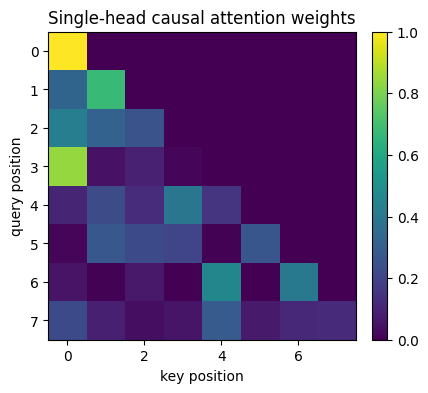

In [75]:
weights0 = prefill_weights[0].detach()
print("row sums:", weights0.sum(dim=-1))

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(weights0, cmap="viridis")
ax.set_title("Single-head causal attention weights")
ax.set_xlabel("key position")
ax.set_ylabel("query position")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.show()

## Decode: One Token Query, Growing KV Cache

During generation, we process one token at a time.

For each token:

1. Project only that token into `q_t`, `k_t`, and `v_t`.
2. Append `k_t` and `v_t` to the cache.
3. Let `q_t` attend over the cache.
4. Return one output token.

No causal mask is needed inside the decode attention call when the cache contains
only allowed previous/current tokens.

In [76]:
def append_cache(cache, new_value):
    if cache is None:
        return new_value
    return torch.cat([cache, new_value], dim=1)


def decode_step_torch(x_t, wq, wk, wv, wo, cache_k=None, cache_v=None):
    q_t, k_t, v_t = project_qkv(x_t, wq, wk, wv)
    cache_k = append_cache(cache_k, k_t)
    cache_v = append_cache(cache_v, v_t)
    attn_out, weights, scores = attention_torch(q_t, cache_k, cache_v, causal=False)
    y_t = attn_out @ wo
    return y_t, cache_k, cache_v, weights, scores


cache_k = None
cache_v = None
decode_outputs = []
decode_rows = []

for token_idx in range(T):
    x_t = x[:, token_idx : token_idx + 1, :]
    y_t, cache_k, cache_v, weights_t, scores_t = decode_step_torch(
        x_t,
        wq,
        wk,
        wv,
        wo,
        cache_k,
        cache_v,
    )
    decode_outputs.append(y_t)
    cache_len = cache_k.shape[1]
    decode_rows.append([token_idx, list(y_t.shape), cache_len, list(weights_t.shape)])

decode_y = torch.cat(decode_outputs, dim=1)
print_table(["step", "y_t", "cache_len", "weights"], decode_rows)

step  y_t         cache_len  weights  
----  ----------  ---------  ---------
0     [2, 1, 12]  1          [2, 1, 1]
1     [2, 1, 12]  2          [2, 1, 2]
2     [2, 1, 12]  3          [2, 1, 3]
3     [2, 1, 12]  4          [2, 1, 4]
4     [2, 1, 12]  5          [2, 1, 5]
5     [2, 1, 12]  6          [2, 1, 6]
6     [2, 1, 12]  7          [2, 1, 7]
7     [2, 1, 12]  8          [2, 1, 8]


## Prefill And Decode Should Match

With the same weights and no dropout, full causal prefill and token-by-token
decode should produce the same outputs.

In [77]:
max_abs_error = (prefill_y - decode_y).abs().max().item()
print(f"max_abs_error = {max_abs_error:.8f}")
print("allclose", torch.allclose(prefill_y, decode_y, atol=1e-5, rtol=1e-5))

max_abs_error = 0.00000024
allclose True


## Three Torch Paths

We now compare three Torch ways to run attention. They are not the same thing.

| Path | What we write | What PyTorch runs | Why we use it |
|---|---|---|---|
| Torch eager | Our explicit `scores -> mask -> softmax -> values` code | Normal PyTorch ops executed immediately | Best readable reference for learning and debugging |
| Torch native SDPA | `F.scaled_dot_product_attention(...)` | PyTorch's built-in attention implementation | Baseline optimized API used by real models when available |
| `torch.compile` | Our eager Python function | A captured/compiled graph of our function | Learn graph capture, fusion, compile overhead, and graph breaks |

Important distinction: native SDPA is a specialized attention operator.
`torch.compile` is not an attention operator; it is a compiler path applied to
our function. On small CPU examples it can be slower even after warmup.


## Torch Native SDPA

PyTorch provides `torch.nn.functional.scaled_dot_product_attention`.

It expects a head dimension, so for single-head attention we temporarily add a
fake head axis:

```text
[B, T, D] -> [B, 1, T, D]
```

In [78]:
def attention_torch_native(q, k, v):
    out = F.scaled_dot_product_attention(
        q.unsqueeze(1),
        k.unsqueeze(1),
        v.unsqueeze(1),
        is_causal=True,
    )
    return out.squeeze(1)


native_out = attention_torch_native(q, k, v)
eager_out, _, _ = attention_torch(q, k, v, causal=True)
print("eager vs native SDPA", torch.allclose(eager_out, native_out, atol=1e-5, rtol=1e-5))
print("max_abs_error", (eager_out - native_out).abs().max().item())

eager vs native SDPA True
max_abs_error 1.1920928955078125e-07


## `torch.compile`: Same Function, Captured Graph

`torch.compile` asks PyTorch to capture and optimize a Python function. The first
call includes compile overhead. Timings below measure after a warmup call.

This step is useful for learning graph breaks, fusion opportunities, and compiler
limits before writing custom kernels.

In [79]:
def attention_torch_output(q, k, v):
    out, _, _ = attention_torch(q, k, v, causal=True)
    return out


compiled_attention = None
compile_status = "not available"
compile_error = None

if hasattr(torch, "compile"):
    try:
        compiled_attention = torch.compile(attention_torch_output, fullgraph=True)
        compiled_out = compiled_attention(q, k, v)
        compile_status = "available"
        print("eager vs compiled", torch.allclose(eager_out, compiled_out, atol=1e-5, rtol=1e-5))
    except Exception as exc:
        compile_error = exc
        compile_status = f"failed: {type(exc).__name__}"

print("compile_status:", compile_status)
if compile_error is not None:
    print(str(compile_error)[:300])

eager vs compiled True
compile_status: available


## Microbenchmark

These numbers describe the runtime used for this notebook execution.

We use separate CPU and CUDA sizes. CPU benchmarks stay moderate so the notebook
is still easy to run. CUDA benchmarks use a larger sequence length so GPU work is
large enough to see beyond launch overhead.

| Device | Shape used | Why |
|---|---|---|
| CPU | `[B=2, T=128, D=64]` | portable notebook timing |
| CUDA | `[B=8, T=1024, D=64]` | enough work for meaningful GPU timing |

Rules for this table:

- NumPy is included for mechanical comparison.
- Torch eager is the readable reference.
- Torch native SDPA is the optimized PyTorch path.
- `torch.compile` is timed after warmup, but it can still be slower than SDPA.

On some CPU/BLAS backends, NumPy matmul can emit floating-point warnings during
timing even when the output is finite. For the benchmark path below we suppress
that warning noise and explicitly check that the output contains only finite
values.


In [80]:
CPU_BENCH = {"batch": 2, "tokens": 128, "dim": 64}
CUDA_BENCH = {"batch": 8, "tokens": 1024, "dim": 64}

rng = np.random.default_rng(123)
q_np_bench = rng.standard_normal(
    (CPU_BENCH["batch"], CPU_BENCH["tokens"], CPU_BENCH["dim"]),
    dtype=np.float32,
)
k_np_bench = rng.standard_normal(q_np_bench.shape, dtype=np.float32)
v_np_bench = rng.standard_normal(q_np_bench.shape, dtype=np.float32)

q_bench = torch.from_numpy(q_np_bench)
k_bench = torch.from_numpy(k_np_bench)
v_bench = torch.from_numpy(v_np_bench)


def attention_numpy_benchmark(q, k, v):
    with np.errstate(over="ignore", divide="ignore", invalid="ignore"):
        out, weights, scores = attention_numpy(q, k, v, causal=True)
    if not np.isfinite(out).all() or not np.isfinite(weights).all():
        raise FloatingPointError("NumPy benchmark produced non-finite output or weights.")
    return out


def time_cuda_ms(fn, *args, warmup=10, iterations=25):
    for _ in range(warmup):
        fn(*args)
    torch.cuda.synchronize()
    start = torch.cuda.Event(enable_timing=True)
    end = torch.cuda.Event(enable_timing=True)
    start.record()
    for _ in range(iterations):
        fn(*args)
    end.record()
    torch.cuda.synchronize()
    return start.elapsed_time(end) / iterations


# Warmups. For torch.compile, the first benchmark-shape call may compile a new graph.
attention_numpy_benchmark(q_np_bench, k_np_bench, v_np_bench)
attention_torch_output(q_bench, k_bench, v_bench)
attention_torch_native(q_bench, k_bench, v_bench)
if compiled_attention is not None:
    for _ in range(3):
        compiled_attention(q_bench, k_bench, v_bench)

benchmark_rows = []
cpu_shape = list(q_bench.shape)

numpy_timer = Timer(
    stmt="attention_numpy_benchmark(q_np_bench, k_np_bench, v_np_bench)",
    globals=globals(),
)
benchmark_rows.append(["NumPy", cpu_shape, f"{numpy_timer.timeit(100).median * 1e6:.1f} us", "CPU"])

eager_timer = Timer(
    stmt="attention_torch_output(q_bench, k_bench, v_bench)",
    globals=globals(),
)
benchmark_rows.append(
    ["Torch eager", cpu_shape, f"{eager_timer.timeit(100).median * 1e6:.1f} us", "CPU"]
)

native_timer = Timer(
    stmt="attention_torch_native(q_bench, k_bench, v_bench)",
    globals=globals(),
)
benchmark_rows.append(
    ["Torch native SDPA", cpu_shape, f"{native_timer.timeit(100).median * 1e6:.1f} us", "CPU"]
)

if compiled_attention is not None:
    compiled_timer = Timer(
        stmt="compiled_attention(q_bench, k_bench, v_bench)",
        globals=globals(),
    )
    compiled_result = f"{compiled_timer.timeit(100).median * 1e6:.1f} us"
else:
    compiled_result = compile_status
benchmark_rows.append(["torch.compile", cpu_shape, compiled_result, "CPU"])

if torch.cuda.is_available():
    q_cuda_bench = torch.randn(
        CUDA_BENCH["batch"],
        CUDA_BENCH["tokens"],
        CUDA_BENCH["dim"],
        device="cuda",
    )
    k_cuda_bench = torch.randn_like(q_cuda_bench)
    v_cuda_bench = torch.randn_like(q_cuda_bench)
    cuda_shape = list(q_cuda_bench.shape)

    eager_cuda_ms = time_cuda_ms(
        attention_torch_output,
        q_cuda_bench,
        k_cuda_bench,
        v_cuda_bench,
    )
    native_cuda_ms = time_cuda_ms(
        attention_torch_native,
        q_cuda_bench,
        k_cuda_bench,
        v_cuda_bench,
    )
    benchmark_rows.append(["Torch eager", cuda_shape, f"{eager_cuda_ms:.3f} ms", "CUDA"])
    benchmark_rows.append(["Torch native SDPA", cuda_shape, f"{native_cuda_ms:.3f} ms", "CUDA"])

    if compiled_attention is not None:
        for _ in range(3):
            compiled_attention(q_cuda_bench, k_cuda_bench, v_cuda_bench)
        compiled_cuda_ms = time_cuda_ms(
            compiled_attention,
            q_cuda_bench,
            k_cuda_bench,
            v_cuda_bench,
        )
        benchmark_rows.append(["torch.compile", cuda_shape, f"{compiled_cuda_ms:.3f} ms", "CUDA"])

print_table(["path", "shape", "median time", "device"], benchmark_rows)
print("finite NumPy benchmark output: True")


path               shape          median time  device
-----------------  -------------  -----------  ------
NumPy              [2, 128, 64]   650.2 us     CPU   
Torch eager        [2, 128, 64]   531.9 us     CPU   
Torch native SDPA  [2, 128, 64]   239.7 us     CPU   
torch.compile      [2, 128, 64]   450.5 us     CPU   
Torch eager        [8, 1024, 64]  2.282 ms     CUDA  
Torch native SDPA  [8, 1024, 64]  1.061 ms     CUDA  
torch.compile      [8, 1024, 64]  1.104 ms     CUDA  
finite NumPy benchmark output: True


## Profiling: What Actually Runs

A benchmark gives one number. A profiler explains where that number came from.

We are going to profile the Torch paths and look for the actual operators behind
the attention call. For our eager implementation, we expect to see separate ops:

```text
matmul -> divide -> mask fill -> softmax -> matmul
```

For native SDPA, we expect fewer, more specialized attention operators. On CUDA,
that difference usually becomes much larger because SDPA can dispatch to kernels
that avoid materializing the full attention matrix.

Profiler columns to read first:

| Column | Meaning |
|---|---|
| `Self CPU` | Time spent inside that operator, excluding child ops |
| `CPU total` | Time including child ops called underneath |
| `CPU Mem` | CPU memory attributed to the op when memory profiling is enabled |
| `CUDA total` | GPU time for kernels launched by that op, visible on CUDA runtimes |
| `# of Calls` | How often the operator ran |
| `Input Shapes` | Tensor shapes observed for the operator |

For CUDA profiling, synchronization matters. GPU work is asynchronous, so timing
or profiling a region without synchronization can make CPU launch time look like
the whole story.


## CPU Operator Profile

First profile CPU execution. This is useful even when the final target is GPU
because it reveals the decomposition of our Python function into PyTorch ops.


In [81]:
def profile_cpu(label, fn, *args, iterations=10, row_limit=8):
    for _ in range(3):
        fn(*args)

    with profile(
        activities=[ProfilerActivity.CPU],
        record_shapes=True,
        profile_memory=True,
    ) as prof:
        with torch.profiler.record_function(label):
            for _ in range(iterations):
                fn(*args)

    print(f"\n{label}")
    print(prof.key_averages(group_by_input_shape=True).table(
        sort_by="cpu_time_total",
        row_limit=row_limit,
    ))


profile_cpu("torch_eager_attention_cpu", attention_torch_output, q_bench, k_bench, v_bench)
profile_cpu("torch_native_sdpa_cpu", attention_torch_native, q_bench, k_bench, v_bench)
if compiled_attention is not None:
    profile_cpu("torch_compile_attention_cpu", compiled_attention, q_bench, k_bench, v_bench)



torch_eager_attention_cpu
-----------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ---------------------------------------  
                         Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg       CPU Mem  Self CPU Mem    # of Calls                             Input Shapes  
-----------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ---------------------------------------  
    torch_eager_attention_cpu        16.74%       1.905ms       100.00%      11.380ms      11.380ms           0 B      -5.97 MB             1                                       []  
                 aten::matmul         2.28%     259.476us        19.72%       2.244ms     224.449us       1.25 MB           0 B            10             [[2, 128, 64], [2, 64, 128]]  
            aten::masked_fill         2.59%     

## Reading The CPU Profile

For the eager path, the important thing is not just the total time. Look at the
operator list. If you see separate `matmul`, `softmax`, `masked_fill`, and
allocation-heavy ops, that means the implementation is materializing intermediate
tensors.

For native SDPA, the table looks more compact because the attention pattern
is represented as a specialized fused operator. This is the first sign that native SDPA
is not simply calling our eager function internally.

For `torch.compile`, the profile tells us whether our Python function became a
smaller compiled graph or still has expensive pieces. If it is slower than native
SDPA, that is expected: compiling our manual function is different from calling a
specialized attention implementation.


## CUDA Operator Profile

When CUDA is available, profile the same paths on larger GPU tensors:

```text
q, k, v: [B=8, T=1024, D=64]
```

The larger shape matters. With tiny tensors like `[2, 64, 64]`, kernel launch and
profiler overhead can dominate, so the table looks confusing. With a larger
sequence length, the profile better exposes actual GPU work.

How to know it is really running on GPU:

- `Self CUDA` or `CUDA total` columns are populated.
- `CUDA Mem` changes are shown.
- CUDA kernel names such as `volta_sgemm...`, `ampere...`, or attention kernels appear.
- native SDPA shows operators such as `aten::scaled_dot_product_attention` and a backend-specific attention forward.

CPU time often includes Python and kernel launch overhead. CUDA time measures the
GPU kernels launched by those ops.


In [82]:
def profile_cuda(label, fn, *args, iterations=5, row_limit=12):
    if not torch.cuda.is_available():
        print(f"{label}: CUDA profile skipped because CUDA is not available in this runtime.")
        return

    for _ in range(5):
        fn(*args)
    torch.cuda.synchronize()

    with profile(
        activities=[ProfilerActivity.CPU, ProfilerActivity.CUDA],
        record_shapes=True,
        profile_memory=True,
    ) as prof:
        with torch.profiler.record_function(label):
            for _ in range(iterations):
                fn(*args)
        torch.cuda.synchronize()

    print(f"\n{label}")
    print(prof.key_averages(group_by_input_shape=True).table(
        sort_by="cuda_time_total",
        row_limit=row_limit,
    ))


if torch.cuda.is_available():
    q_cuda_profile = torch.randn(
        CUDA_BENCH["batch"],
        CUDA_BENCH["tokens"],
        CUDA_BENCH["dim"],
        device="cuda",
    )
    k_cuda_profile = torch.randn_like(q_cuda_profile)
    v_cuda_profile = torch.randn_like(q_cuda_profile)

    print_table(
        ["profile tensor", "shape", "device"],
        [
            ["q_cuda_profile", list(q_cuda_profile.shape), q_cuda_profile.device],
            ["k_cuda_profile", list(k_cuda_profile.shape), k_cuda_profile.device],
            ["v_cuda_profile", list(v_cuda_profile.shape), v_cuda_profile.device],
        ],
    )

    profile_cuda(
        "torch_eager_attention_cuda",
        attention_torch_output,
        q_cuda_profile,
        k_cuda_profile,
        v_cuda_profile,
    )
    profile_cuda(
        "torch_native_sdpa_cuda",
        attention_torch_native,
        q_cuda_profile,
        k_cuda_profile,
        v_cuda_profile,
    )
    if compiled_attention is not None:
        for _ in range(3):
            compiled_attention(q_cuda_profile, k_cuda_profile, v_cuda_profile)
        torch.cuda.synchronize()
        profile_cuda(
            "torch_compile_attention_cuda",
            compiled_attention,
            q_cuda_profile,
            k_cuda_profile,
            v_cuda_profile,
        )
else:
    print("CUDA profile skipped because CUDA is not available in this runtime.")


profile tensor  shape          device
--------------  -------------  ------
q_cuda_profile  [8, 1024, 64]  cuda:0
k_cuda_profile  [8, 1024, 64]  cuda:0
v_cuda_profile  [8, 1024, 64]  cuda:0

torch_eager_attention_cuda
------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------------------------------------  
                          Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg       CPU Mem  Self CPU Mem      CUDA Mem  Self CUDA Mem    # of Calls                                Input Shapes  
------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------------------------------------  
    torch_eager_attention_cuda         6.62%     881.940us        54.14%       7.208ms       7.208ms           0 B           0 B  

## Reading The CUDA Profile

The profile you saw with `volta_sgemm...` was running on GPU. Treat that as a
CUDA kernel name from the backend library, not as a reliable label for the exact
GPU architecture.

For eager attention, expect several separate GPU kernels:

- one batched matmul for `q @ k.T`
- masking / fill work
- a softmax kernel
- one batched matmul for `weights @ v`

That path materializes intermediate tensors like `scores` and `weights`.

For native SDPA, expect a specialized attention path. On CUDA this may dispatch
to a memory-efficient attention backend, which is why it can be much faster than
both eager and `torch.compile`.

For `torch.compile`, remember the distinction: it compiles our manual attention
function. It is not automatically the same thing as native SDPA or a Flash-style
attention kernel. If Inductor warns that online softmax is disabled, that means
it could not use the streaming softmax strategy for this compiled graph.


## Next Step

We built attention from dot products up to Torch SDPA, then looked at how
prefill, decode, KV cache, benchmarking, and profiling fit together. The main
thing is simple: attention math is one part, and inference behavior is another.

From here we take the same operation and add heads. That changes the tensor
layout from:

```text
single-head: q, k, v = [B, T, D]
multi-head:  q, k, v = [B, H, T, D]
```

Once the head axis is clear, MQA, GQA, MLA, sparse attention, FlashAttention,
FlexAttention, and Triton kernels become much easier to reason about.
